# CMRM Homework Assignment No. 1 (HW1)

In [23]:
import os
import librosa
import numpy as np
import matplotlib.pyplot as plt
# import other libraries
import deeplake
from tqdm import tqdm
from sklearn.preprocessing import MinMaxScaler
import sklearn
from sklearn import svm
import joblib
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
import seaborn as sns

## Question 1

### GTZAN Dataset information

In [24]:
# Import dataset
ds = deeplake.load("hub://activeloop/gtzan-genre")

tensor_genre = ds.genre     # definition of genre tensor
tensor_audio = ds.audio     # definition of audio tensor

# Printing different characteristics related to the dataset
print("Tensors:\n", ds.tensors)
print("Tensor_audio:\n", tensor_audio)
print("Tensor_audio key:\n", tensor_audio.key)
print("Tensor_audio shape:\n", np.shape(tensor_audio))
print("Tensor_genre:\n", tensor_genre)
print("Tensor_genre key:\n", tensor_genre.key)
print("Tensor_genre shape:\n", np.shape(tensor_genre))

\

Opening dataset in read-only mode as you don't have write permissions.


-

This dataset can be visualized in Jupyter Notebook by ds.visualize() or at https://app.activeloop.ai/activeloop/gtzan-genre



\

hub://activeloop/gtzan-genre loaded successfully.



Tensors:
 {'audio': Tensor(key='audio'), 'genre': Tensor(key='genre')}
Tensor_audio:
 Tensor(key='audio')
Tensor_audio key:
 audio
Tensor_audio shape:
 (1000, None, 1)
Tensor_genre:
 Tensor(key='genre')
Tensor_genre key:
 genre
Tensor_genre shape:
 (1000, 1)


### Tracks extraction

In [25]:
Fs = 22050      # sample rate of wav files
n_samples = 29 * Fs         # duration in samples 
n_wav = len(tensor_audio)       # number of audio files (1000)

# Define downsampling factors
sub_train = 10
sub_test = 52

# Extract classes
genre_names = ["pop", "metal", "classical", "rock", "blues", "jazz", "hiphop", "reggae", "disco", "country"]

# Dictionary for genre names mapping
genre_mapping = {
    0: "pop",
    1: "metal",
    2: "classical",
    3: "rock",
    4: "blues",
    5: "jazz",
    6: "hiphop",
    7: "reggae",
    8: "disco",
    9: "country"
}

# Defining tensor_genre with genre names instead of numbers
tensor_genre_names = [genre_mapping[i[0].numpy(aslist=True)] for i in tensor_genre]

# Define lists indices
index_training = list(range(0, n_wav, sub_train))       # training songs from 0 to n_wav with sub_train step
index_test = list(range(11, n_wav, sub_test))           # test songs from 0 to n_wav with sub_test step

print("Training_index:\n", index_training)      # showing the indices of extracted songs for training
print("Test_index:\n", index_test)              # showing the indices of extracted songs for test

# Define lists with extracted samples
genre_train = np.take(tensor_genre, index_training, axis = 0)       # taking songs' genre from the genre tensor using the indexes
genre_test = np.take(tensor_genre, index_test, axis = 0)            # taking songs' genre from the genre tensor using the indexes

print("Shape of genre_train:\n", np.shape(genre_train))         # showing the shape of genre_train
print("Shape of genre_test:\n", np.shape(genre_test))           # showing the shape of genre_test

# Extract training set
audio_train = []        # defining training set

for i in tqdm(index_training, desc = "Extracting songs for the training set"):
    audio_train.append(tensor_audio[i, 0 : n_samples, 0].numpy(aslist = True))      # extracting songs from audio tensor and appending to the training set

print("Shape of audio_train:\n", np.shape(audio_train))     # showing the shape of training set

# Extract test set
audio_test = []     # defining test set

for i in tqdm(index_test, desc = "Extracting songs for the test set"):
    audio_test.append(tensor_audio[i, 0 : n_samples, 0].numpy(aslist = True))       # extracting songs from audio tensor and appending to the test set

print("Shape of audio_test:\n", np.shape(audio_test))       # showing the shape of test set

Training_index:
 [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150, 160, 170, 180, 190, 200, 210, 220, 230, 240, 250, 260, 270, 280, 290, 300, 310, 320, 330, 340, 350, 360, 370, 380, 390, 400, 410, 420, 430, 440, 450, 460, 470, 480, 490, 500, 510, 520, 530, 540, 550, 560, 570, 580, 590, 600, 610, 620, 630, 640, 650, 660, 670, 680, 690, 700, 710, 720, 730, 740, 750, 760, 770, 780, 790, 800, 810, 820, 830, 840, 850, 860, 870, 880, 890, 900, 910, 920, 930, 940, 950, 960, 970, 980, 990]
Test_index:
 [11, 63, 115, 167, 219, 271, 323, 375, 427, 479, 531, 583, 635, 687, 739, 791, 843, 895, 947, 999]
Shape of genre_train:
 (100, 1)
Shape of genre_test:
 (20, 1)


Extracting songs for the training set: 100%|██████████| 100/100 [01:11<00:00,  1.40it/s]


Shape of audio_train:
 (100, 639450)


Extracting songs for the test set: 100%|██████████| 20/20 [00:13<00:00,  1.43it/s]

Shape of audio_test:
 (20, 639450)


Text(0, 0.5, 'Amplitude')

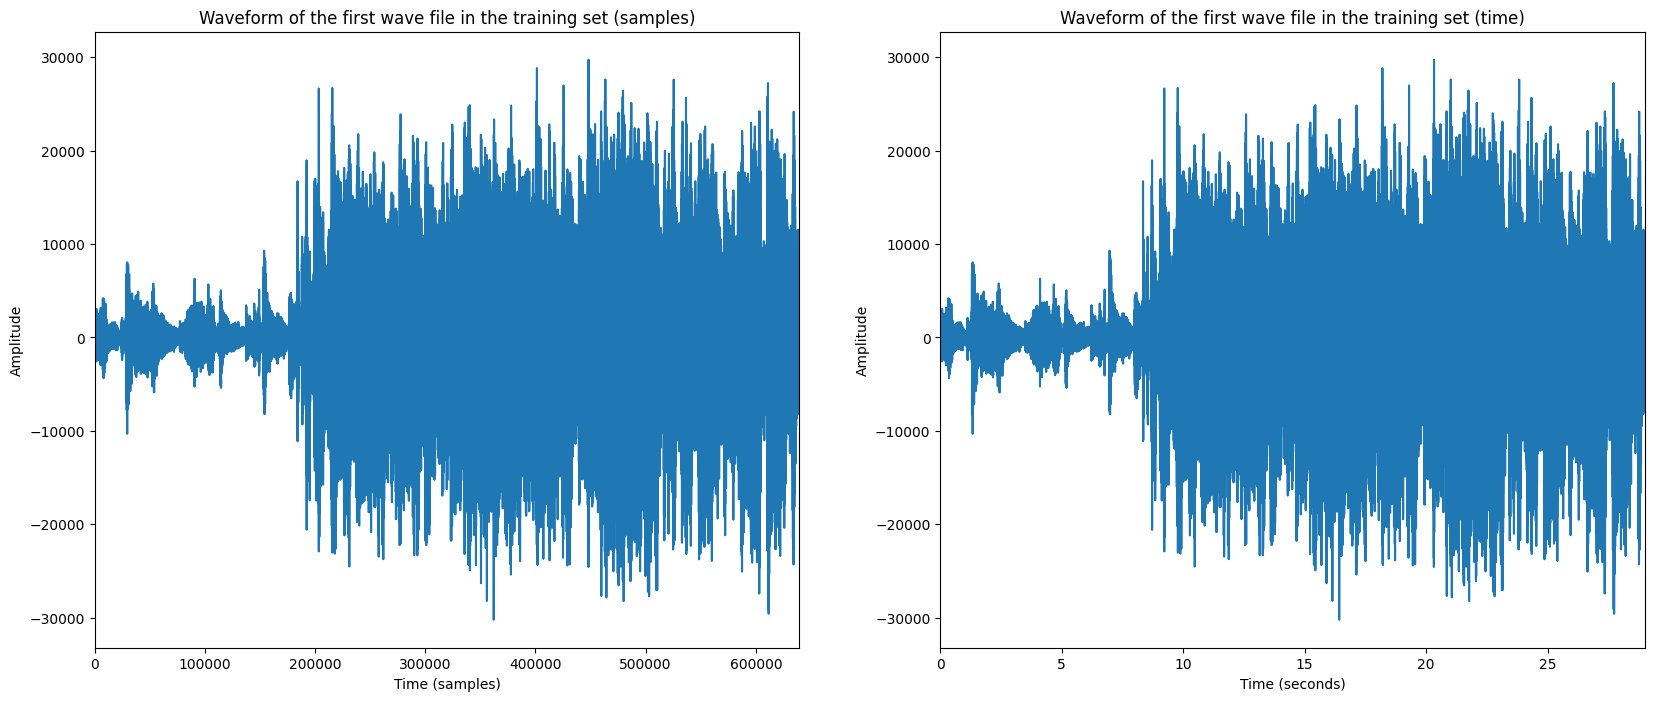

In [26]:
# Plot the first wav in the train set
plt.figure(figsize = (20, 8))

# Subplot for representation in samples
plt.subplot(1, 2, 1)
plt.title("Waveform of the first wave file in the training set (samples)")
plt.plot(audio_train[0])
plt.xlim(0, n_samples)
plt.xlabel("Time (samples)")
plt.ylabel("Amplitude")

# Subplot for representation in seconds
time_axis = np.arange(len(audio_train[1])) / Fs

plt.subplot(1, 2, 2)
plt.title("Waveform of the first wave file in the training set (time)")
plt.plot(time_axis, audio_train[0])
plt.xlim(0, time_axis[-1])
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")

## Question 2

### Pre-processing scaling

In [27]:
# Define MinMaxScaler
scaler = MinMaxScaler((-1, 1))
scaled_audio_train = scaler.fit_transform(audio_train)
scaled_audio_test = scaler.fit_transform(audio_test)

Text(0, 0.5, 'Amplitude (samples)')

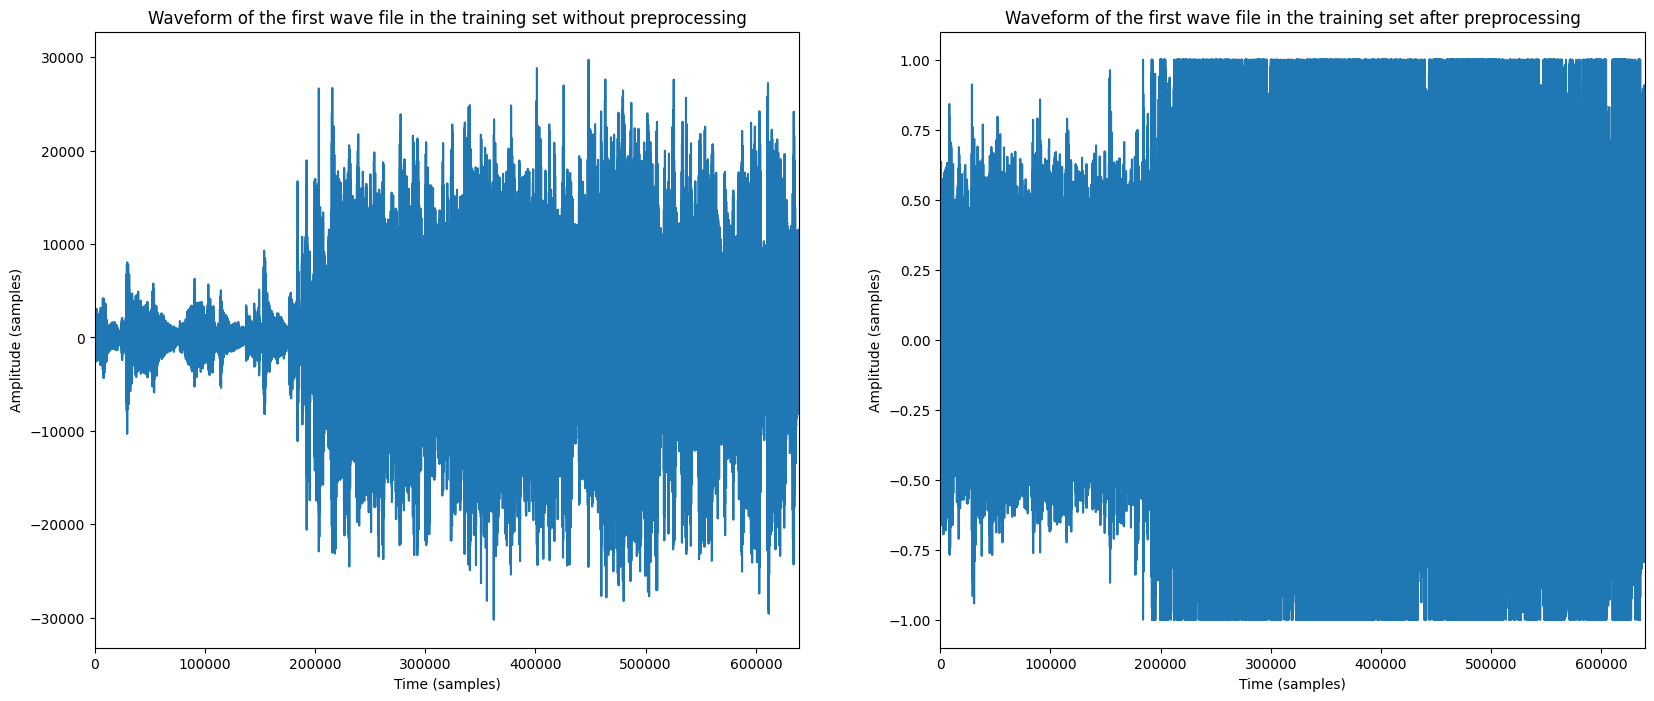

In [28]:
# Plot the first wav in the train set after preprocessing
plt.figure(figsize = (20, 8))

# Subplot for original audio waveform
plt.subplot(1, 2, 1)
plt.title("Waveform of the first wave file in the training set without preprocessing")
plt.plot(audio_train[0])
plt.xlim(0, n_samples)
plt.xlabel("Time (samples)")
plt.ylabel("Amplitude (samples)")

# Subplot for scaled audio waveform
plt.subplot(1, 2, 2)
plt.title("Waveform of the first wave file in the training set after preprocessing")
plt.plot(scaled_audio_train[0])
plt.xlim(0, n_samples)
plt.xlabel("Time (samples)")
plt.ylabel("Amplitude (samples)")

In [29]:
# Preprocessing
audio_train = scaler.fit_transform(audio_train)
audio_test = scaler.fit_transform(audio_test)

### Phase novelty function

In [30]:
# Compute local average
def compute_local_average(x, M):
    """Compute local average of signal

    Args:
        x: Signal
        M: Total length in samples of centric window used for local average

    Returns:
        local_average: Local average signal
    """
    
    L = len(x)

    local_average = np.zeros(L)     # defining local_average as an L samples long array

    for m in range(L):
        a = max(m - M, 0)       # defining x[a]
        b = min(m + M + 1, L)       # defining x[b]
        local_average[m] = (1 / (2 * M + 1)) * np.sum(x[a : b])       # taking the sum of elements between x[a] and x[b-1], then multiplying by 1 / 2M + 1

    return local_average

# Compute the principal argument
def principal_argument(x):
    """Principal argument function 
    
    Args:
        x: value (or vector of values)
        
    Returns:
        y: Principal value of x
    """
    
    y = np.mod(x + 0.5, 1) - 0.5        # mapping the phase differences into [-0.5, 0.5]
    
    return y

# Compute the Phase-Based Novelty function
def compute_phase_novelty(x, Fs = 22050, N = 1024, H = 64, M = 40, norm = True, plot = False):
    """Compute phase-based novelty function

    Args:
        x: Signal
        Fs: Sampling rate
        N: Window size
        H: Hop size
        M: Total length in samples of centric window  used for local average
        norm: Apply max norm (if norm == True)
        plot: Plot novelty (if plot == True)

    Returns:
        nov: Phase-based novelty function
        Fs_nov: Novelty rate
    """
    
    # Compute the STFT
    X = librosa.stft(x, n_fft=N, hop_length=H, win_length=N, window='hann')     # computing STFT using N samples for the windowed audio signal,
                                                                                # H samples for hop size, N samples for the "hann" window's length
    
    # Compute the novelty rate
    Fs_nov = Fs / H
    
    # Extract the phase and use principal_argument
    phase = np.angle(X) / (2 * np.pi)           # defining the phase from the STFT normalized by 2 * PI
    phase_diff = np.diff(phase, axis = 1)           # first derivative of the phase through columns (time axis)
    phase_diff = principal_argument(phase_diff)         # mapping correctly the phase variation
    phase_diff2 = np.diff(phase_diff, axis = 1)         # second derivative of the phase
    phase_diff2 = principal_argument(phase_diff2)       # mapping correctly the second derivative
    
    # Accumulation over frequency axis
    nov = np.sum(np.abs(phase_diff2), axis = 0)     # summing absolute values of phase_diff2 along rows (frequency axis)
    nov = np.concatenate((nov, np.array([0, 0])))       # adding the two elements lost with each np.diff()
    
    # Local average subtraction and half-wave rectification
    if M > 0:
        local_average = compute_local_average(nov, M)       # local_average computation
        nov = nov - local_average       # subtracting the local average
        nov[nov < 0] = 0        # half-wave rectification
    
    # Normalization
    if norm:
        max_value = np.max(nov)     # maximum value of the novelty
        if max_value > 0:
            nov = nov / max_value       # normalization
    
    # Plot
    nov_time = np.arange(nov.shape[0]) / Fs_nov     # defining the temporal axis

    if plot:
        plt.figure(figsize=(20, 8))
        plt.plot(nov_time, nov)
        plt.title("Phase novelty function with N=" + str(N) + ", H=" + str(H) + ", M=" + str(M))
        plt.xlim(min(nov_time), max(nov_time))
        plt.ylim(min(nov), max(nov))
        plt.xlabel("Time (seconds)")
        plt.ylabel("Novelty")
    
    return nov, Fs_nov

### Parameters influence

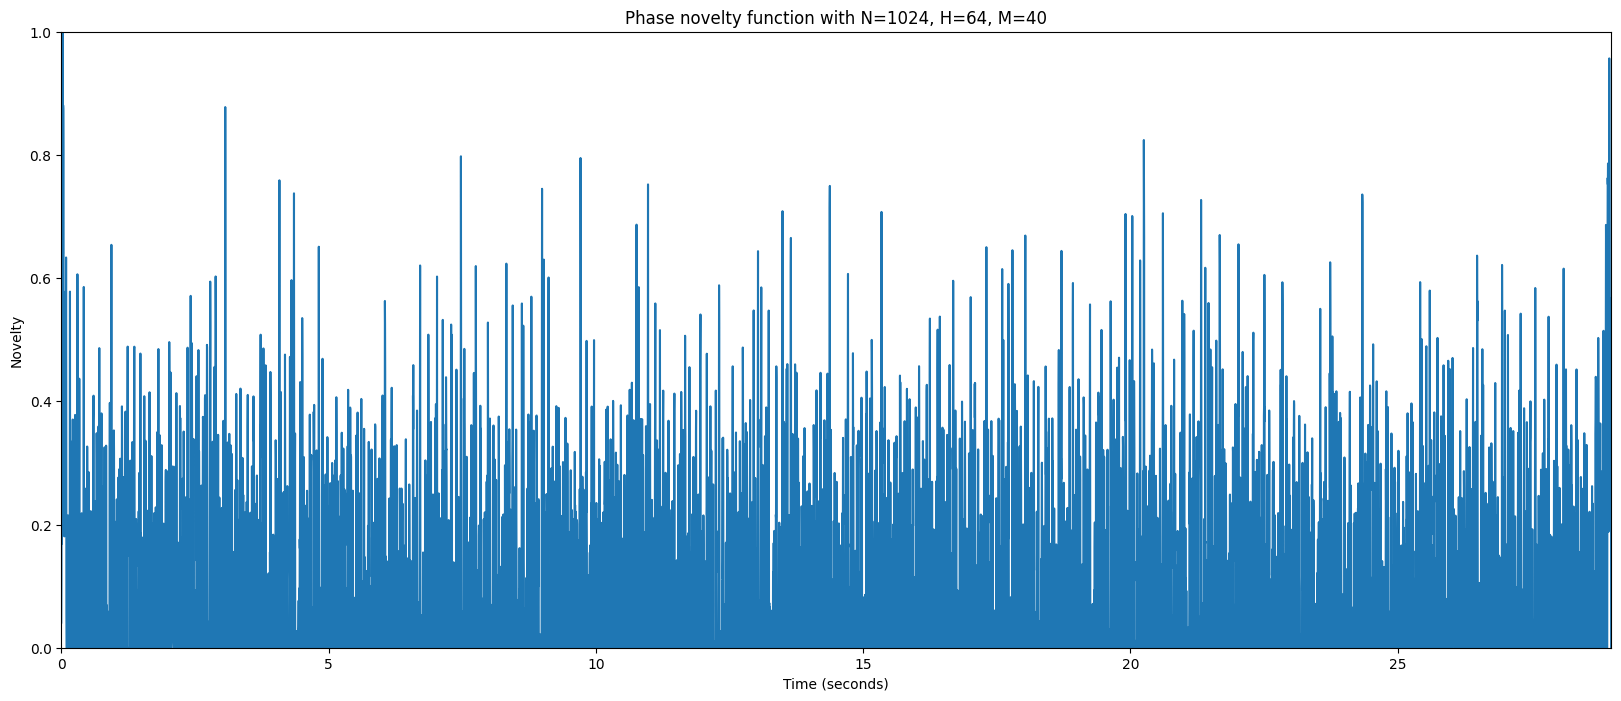

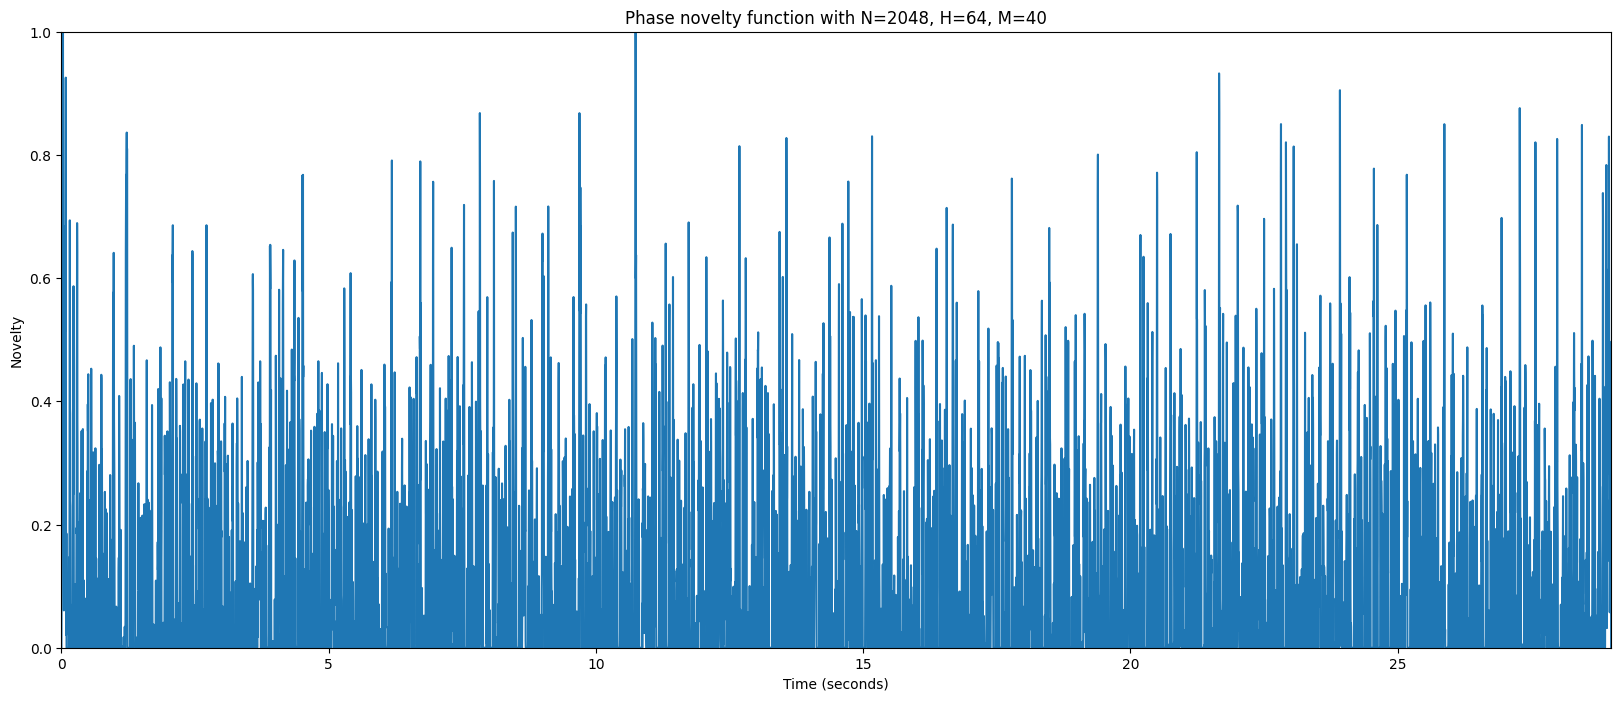

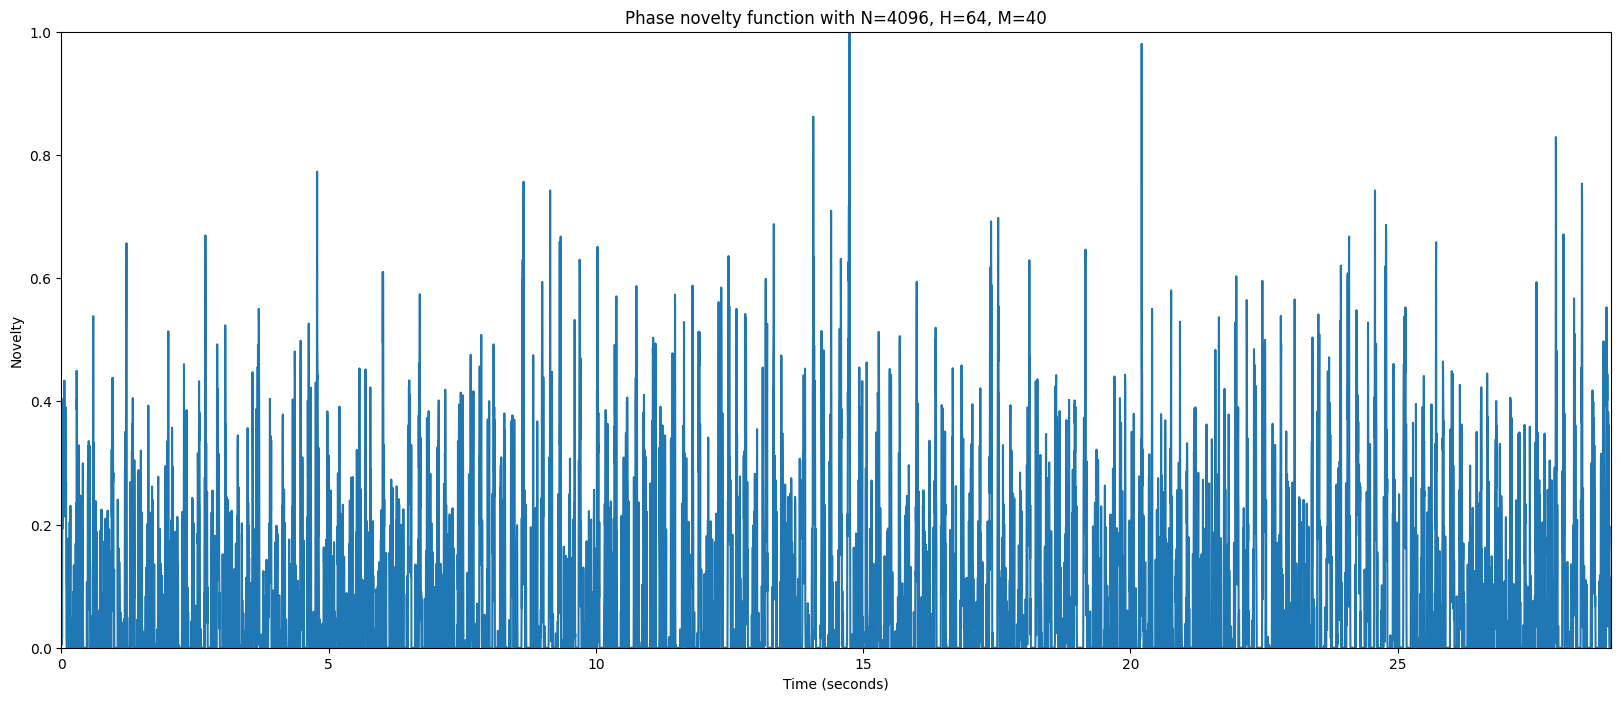

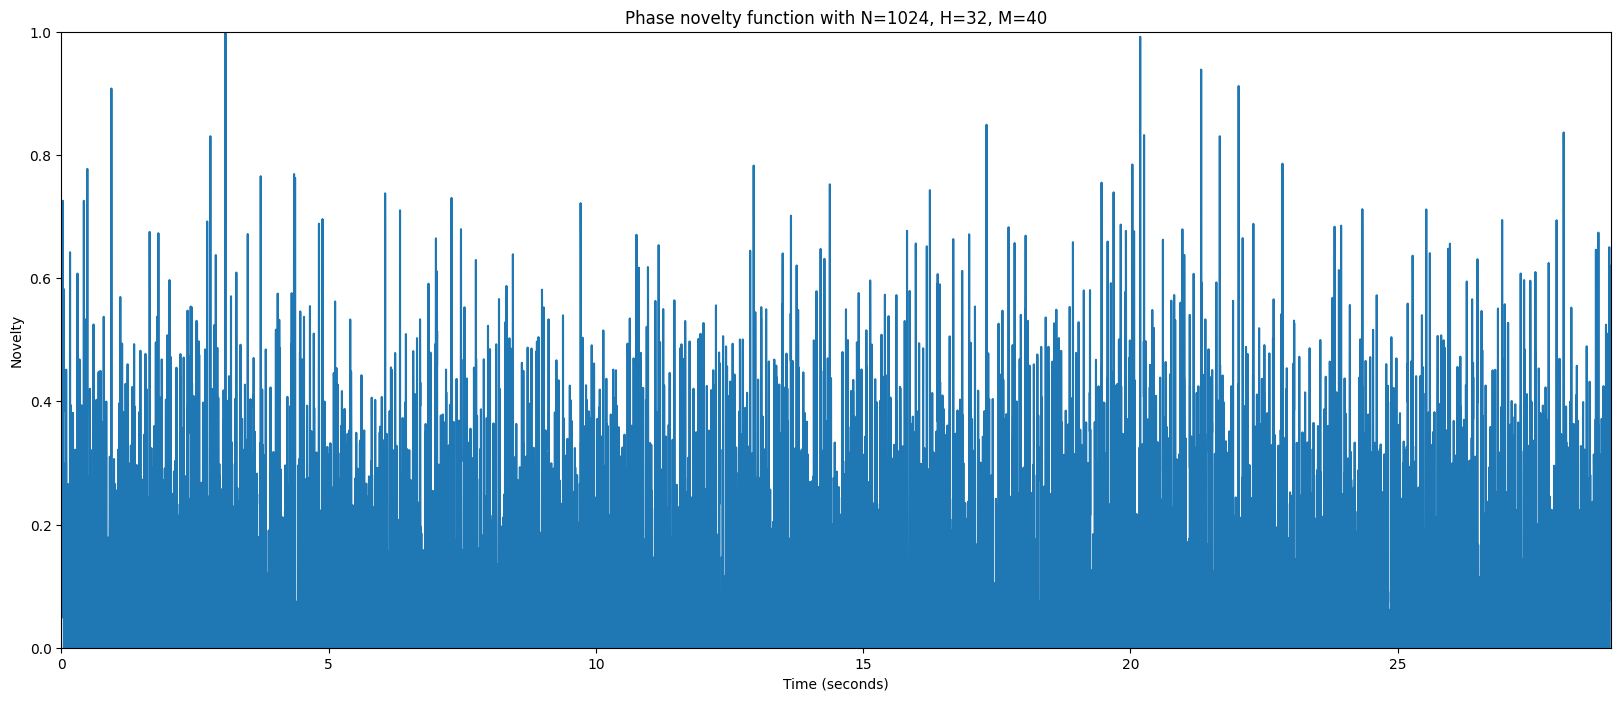

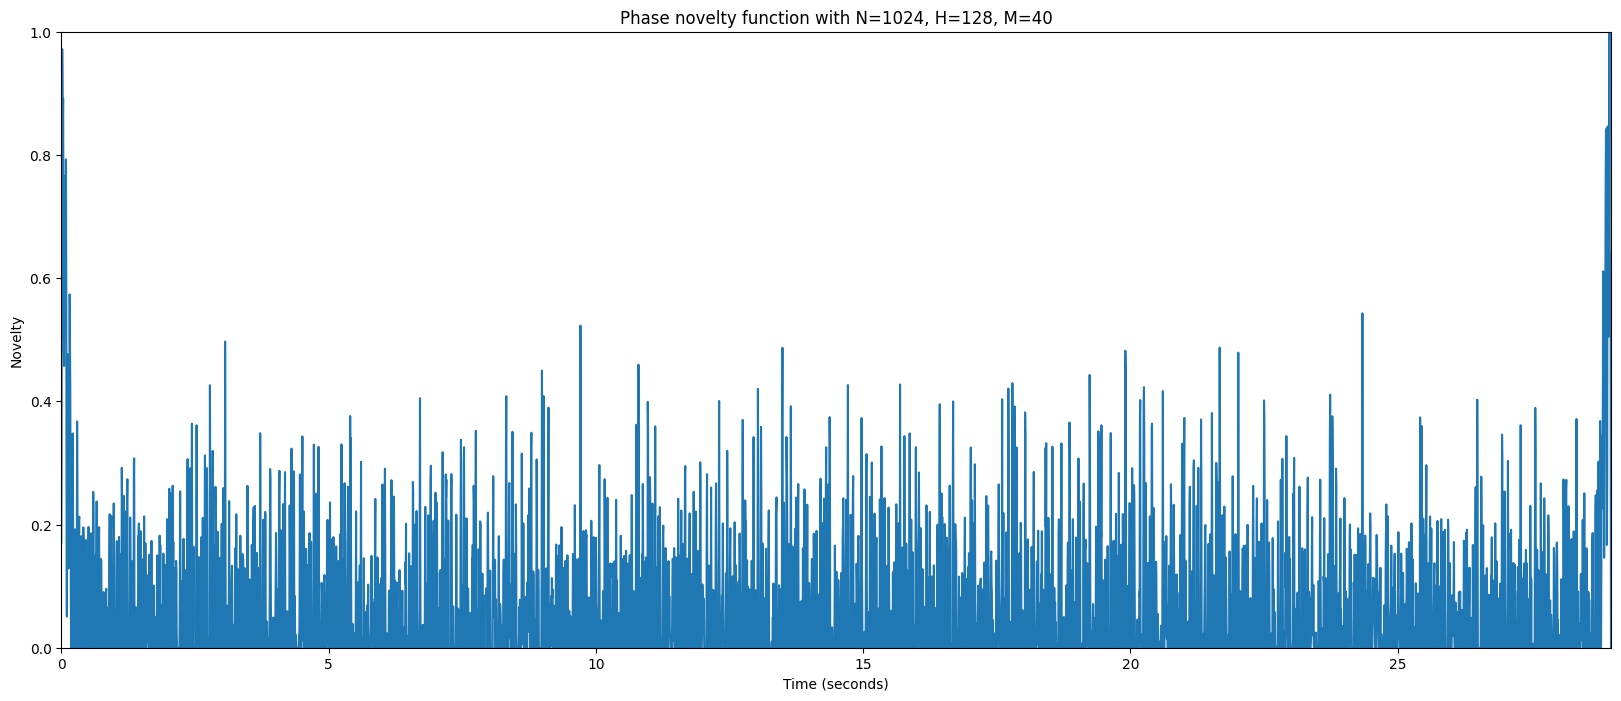

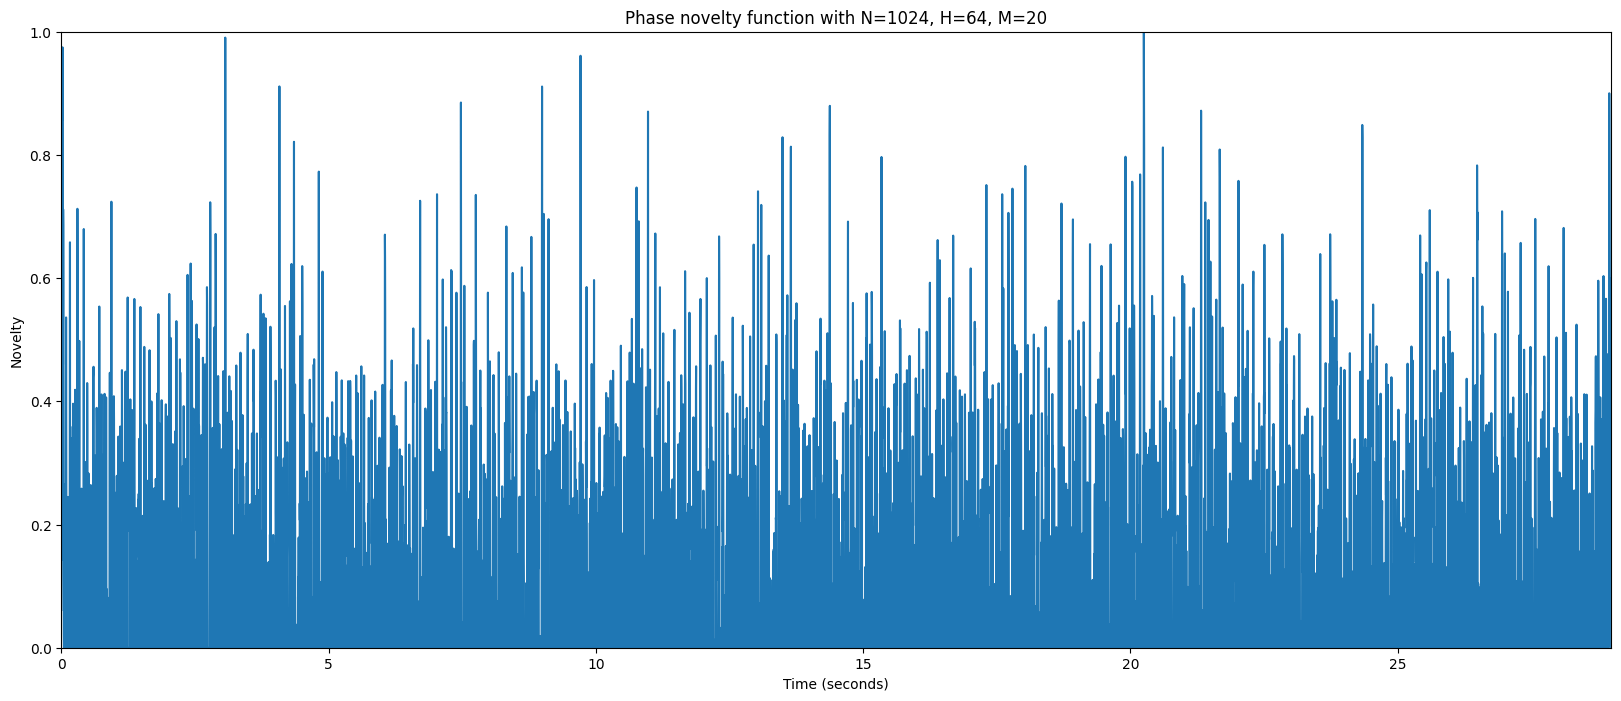

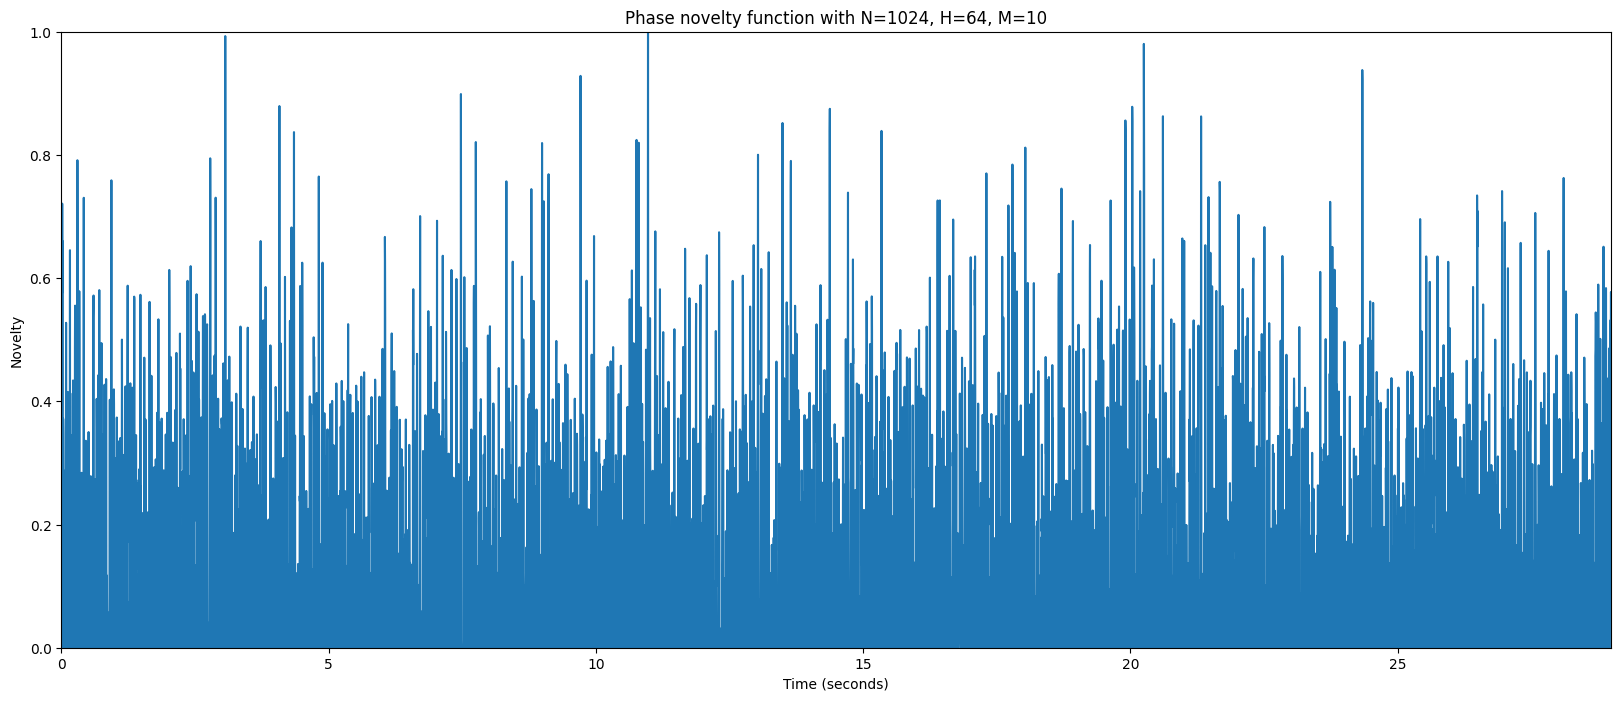

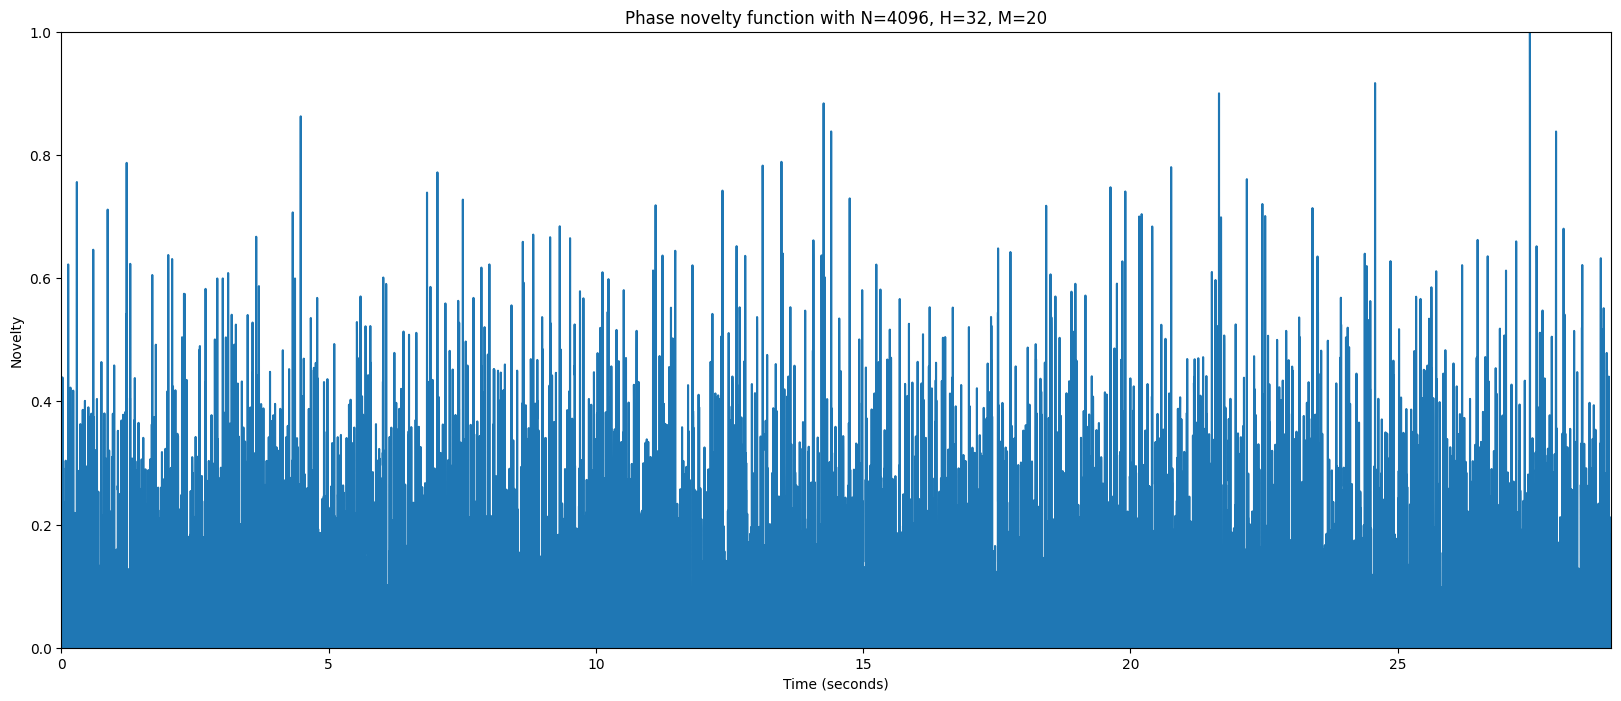

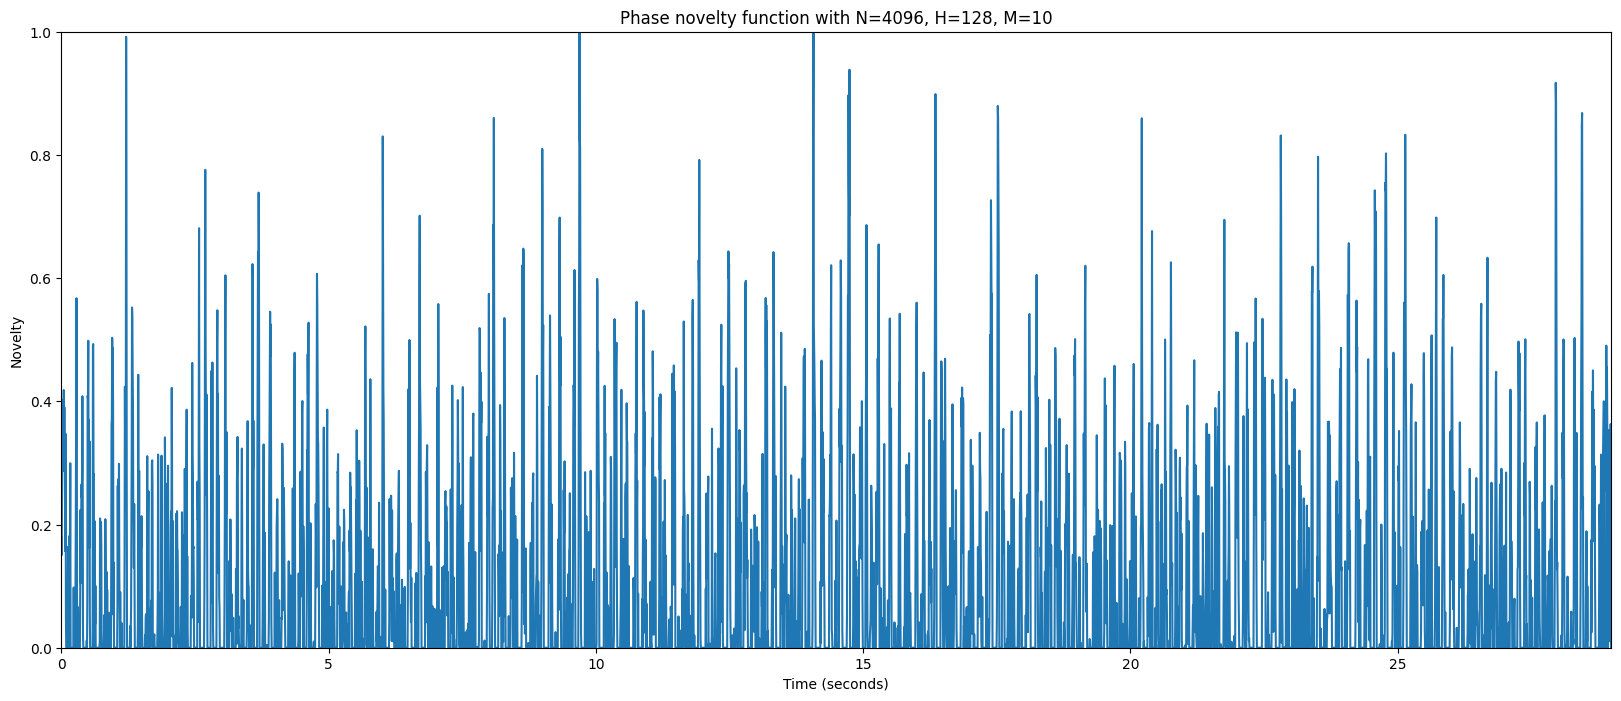

In [31]:
# Test the novelty function on the first wav in the train set
Fs = 22050

novelty, Fs_novelty = compute_phase_novelty(audio_train[0], Fs = Fs, N = 1024, H = 64, M = 40, norm = True, plot = True)

novelty, Fs_novelty = compute_phase_novelty(audio_train[0], Fs=Fs, N=2048, H=64, M=40, norm=True, plot=True)
novelty, Fs_novelty = compute_phase_novelty(audio_train[0], Fs=Fs, N=4096, H=64, M=40, norm=True, plot=True)
novelty, Fs_novelty = compute_phase_novelty(audio_train[0], Fs=Fs, N=1024, H=32, M=40, norm=True, plot=True)
novelty, Fs_novelty = compute_phase_novelty(audio_train[0], Fs=Fs, N=1024, H=128, M=40, norm=True, plot=True)
novelty, Fs_novelty = compute_phase_novelty(audio_train[0], Fs=Fs, N=1024, H=64, M=20, norm=True, plot=True)
novelty, Fs_novelty = compute_phase_novelty(audio_train[0], Fs=Fs, N=1024, H=64, M=10, norm=True, plot=True)
novelty, Fs_novelty = compute_phase_novelty(audio_train[0], Fs=Fs, N=4096, H=32, M=20, norm=True, plot=True)
novelty, Fs_novelty = compute_phase_novelty(audio_train[0], Fs=Fs, N=4096, H=128, M=10, norm=True, plot=True)   # best novelty function

## Question 3

### Vector of rhythmic features

In [32]:
def compute_feature_vector(x, Fs, N=2048, H=128):
    """Compute the feature vector 

    Args:
        x: Input signal
        Fs: Sampling rate
        N: Window length
        H: Hop size

    Returns:
        f_vector: Feature vector
    """

    # Phase novelty function
    nov, Fs_nov = compute_phase_novelty(x, Fs = Fs, N = N, H = H, M = 40, norm = True, plot = False)

    # Standard deviation of novelty function
    stdev_nov = np.std(nov)
    # Mean value of novelty function
    mean_nov = np.mean(nov)
    
    # Zero-crossing rate
    zcr = librosa.feature.zero_crossing_rate(y = x, frame_length = N, hop_length = H, center = True)

    # Standard deviation of zero-crossing rate
    stdev_zcr = np.std(zcr)
    # Mean value of zero-crossing rate
    mean_zcr = np.mean(zcr)

    # Spectral flux
    sf = librosa.onset.onset_strength(y = x, sr = Fs, S = None, lag = 1, max_size = 1, ref = None, detrend = False, center = True, feature = None, aggregate = None)

    # Standard deviation of spectral flux
    stdev_sf = np.std(sf)
    # Mean value of spectral flux
    mean_sf = np.mean(sf)

    # Tempogram
    tempogram = librosa.feature.tempogram(y = x, sr = Fs, onset_envelope = sf, hop_length = H, win_length = N, center = True, window = 'hann', norm = None)

    # Tempo
    tempo = librosa.beat.tempo(y = x, sr = Fs, onset_envelope = sf, hop_length = H, start_bpm = 120, std_bpm = 1.0, ac_size = 8.0, max_tempo = 320.0, aggregate = None, prior = None)
    
    # Concatenate numpy arrays
    f_vector = np.concatenate([nov, [stdev_nov, mean_nov], np.ravel(tempogram), np.ravel(zcr), [stdev_zcr, mean_zcr], sf, [stdev_sf, mean_sf], tempo])
    
    return f_vector

In [33]:
N = 2048
H = 128

# Compute feature vector for all the audio files inside the training set
train_fvector = []      # feature vector for training set

for i in tqdm(range(len(audio_train)), desc = "Computing train_fvector"):
    train_fvector.append(compute_feature_vector(audio_train[i], Fs, N = N, H = H))  # computing features for each song and
                                                                                    # appending to train_fvector

# Compute feature vector for all the audio files inside the test set
test_fvector = []       # feature vector for test set

for i in tqdm(range(len(audio_test)), desc = "Computing test_fvector"):
    test_fvector.append(compute_feature_vector(audio_test[i], Fs, N = N, H = H))    # computing features for each song and
                                                                                    # appending to test_fvector


Computing train_fvector:   0%|          | 0/100 [00:00<?, ?it/s]C:\Users\Giuliano\AppData\Local\Temp\ipykernel_10404\2191744615.py:46: FutureWarning: librosa.beat.tempo
	This function was moved to 'librosa.feature.rhythm.tempo' in librosa version 0.10.0.
	This alias will be removed in librosa version 1.0.
  tempo = librosa.beat.tempo(y = x, sr = Fs, onset_envelope = sf, hop_length = H, start_bpm = 120, std_bpm = 1.0, ac_size = 8.0, max_tempo = 320.0, aggregate = None, prior = None)
Computing test_fvector: 100%|██████████| 20/20 [00:15<00:00,  1.29it/s]


### Feature vector's length

In [34]:
# Check train_fvector and genre_train shapes
print(np.shape(train_fvector))
print(np.shape(genre_train))

(100, 2570448)
(100, 1)


## Question 4

### Models training

In [35]:
# Define model parameters
C = 1
kernel = "linear"

if not os.path.exists("my_model/"):
    os.mkdir("my_model/")

# Train SVC
simple_classifier = sklearn.svm.SVC(C=C, kernel=kernel)     # defining the simplest model
simple_classifier.fit(train_fvector, np.ravel(genre_train))   # training it with the features of training

simple_model = f"my_model/svc_{kernel}_C_{C}_N_{N}_H_{H}.joblib"     # name of the model
joblib.dump(simple_classifier, simple_model)    # saving the model


def load_or_train_svm_model(X, y, C, kernel):
    """Function for loading / training a SVM model

    Args:
        X: Vector of features
        y: Vector of labels
        C: C value for model training
        kernel: Kernel type for model training

    Return:
        model: SVM model

    """

    model_file_name = f"my_model/svc_{kernel}_C_{C}_N_{N}_H_{H}.joblib"      # name of the model

    if os.path.exists(model_file_name):
        model = joblib.load(model_file_name)    # loading the pre-trained model
    else:
        model = svm.SVC(C=C, kernel=kernel)     # defining a new model
        model.fit(X, y)                     # training the new model
        joblib.dump(model, model_file_name)     # saving the new model

    return model

# Computing every settings combination
C_values = [0.01, 0.1, 1, 10, 100]      # different values for C
kernel_values = ["linear", "poly", "rbf", "sigmoid"]        # different values for kernel

model_train = []        # array for saving all models

for c in C_values:
    for k in kernel_values:
        print(c, k)     # showing which combination is working on
        model_train.append(load_or_train_svm_model(train_fvector, np.ravel(genre_train), c, k))     # creating new model with c and k
                                                                                                    # and appending it into model_train

0.01 linear
0.01 poly
0.01 rbf
0.01 sigmoid
0.1 linear
0.1 poly
0.1 rbf
0.1 sigmoid
1 linear
1 poly
1 rbf
1 sigmoid
10 linear
10 poly
10 rbf
10 sigmoid
100 linear
100 poly
100 rbf
100 sigmoid


### Training set accuracy

In [36]:
# Print the accuracy on the training set
best_models = []        # array to save only the models with 100% accuracy on training set

for m in model_train:
    y_train_pred = m.predict(train_fvector)     # prediction for every model of the training set
    accuracy = accuracy_score(np.ravel(genre_train), y_train_pred)      # accuracy of the prediction
                                                                        # in relation to the already-known genre
    print(m)        # showing the model
    print(f"Accuracy on the training set: {accuracy:.2%}")      # showing the model accuracy (%)
    if (accuracy > 0.9):            # only if accuracy over 90%
        best_models.append(m)       # saving the model


SVC(C=0.01, kernel='linear')
Accuracy on the training set: 100.00%
SVC(C=0.01, kernel='poly')
Accuracy on the training set: 27.00%
SVC(C=0.01)
Accuracy on the training set: 34.00%
SVC(C=0.01, kernel='sigmoid')
Accuracy on the training set: 7.00%
SVC(C=0.1, kernel='linear')
Accuracy on the training set: 100.00%
SVC(C=0.1, kernel='poly')
Accuracy on the training set: 27.00%
SVC(C=0.1)
Accuracy on the training set: 34.00%
SVC(C=0.1, kernel='sigmoid')
Accuracy on the training set: 7.00%
SVC(C=1, kernel='linear')
Accuracy on the training set: 100.00%
SVC(C=1, kernel='poly')
Accuracy on the training set: 27.00%
SVC(C=1)
Accuracy on the training set: 34.00%
SVC(C=1, kernel='sigmoid')
Accuracy on the training set: 7.00%
SVC(C=10, kernel='linear')
Accuracy on the training set: 100.00%
SVC(C=10, kernel='poly')
Accuracy on the training set: 42.00%
SVC(C=10)
Accuracy on the training set: 38.00%
SVC(C=10, kernel='sigmoid')
Accuracy on the training set: 7.00%
SVC(C=100, kernel='linear')
Accuracy on 

## Question 5

### Test set accuracy

In [37]:
# Classify the test set
for m in model_train:
    y_test_pred = m.predict(test_fvector)       # prediction for every model of the test set
    accuracy = accuracy_score(np.ravel(genre_test), y_test_pred)      # accuracy of the prediction
    print(m)    # showing the model
    print(f"Accuracy on the test set: {accuracy:.2%}")          # showing the model accuracy (%)

SVC(C=0.01, kernel='linear')
Accuracy on the test set: 15.00%
SVC(C=0.01, kernel='poly')
Accuracy on the test set: 15.00%
SVC(C=0.01)
Accuracy on the test set: 15.00%
SVC(C=0.01, kernel='sigmoid')
Accuracy on the test set: 0.00%
SVC(C=0.1, kernel='linear')
Accuracy on the test set: 15.00%
SVC(C=0.1, kernel='poly')
Accuracy on the test set: 15.00%
SVC(C=0.1)
Accuracy on the test set: 15.00%
SVC(C=0.1, kernel='sigmoid')
Accuracy on the test set: 0.00%
SVC(C=1, kernel='linear')
Accuracy on the test set: 15.00%
SVC(C=1, kernel='poly')
Accuracy on the test set: 15.00%
SVC(C=1)
Accuracy on the test set: 15.00%
SVC(C=1, kernel='sigmoid')
Accuracy on the test set: 0.00%
SVC(C=10, kernel='linear')
Accuracy on the test set: 15.00%
SVC(C=10, kernel='poly')
Accuracy on the test set: 10.00%
SVC(C=10)
Accuracy on the test set: 10.00%
SVC(C=10, kernel='sigmoid')
Accuracy on the test set: 0.00%
SVC(C=100, kernel='linear')
Accuracy on the test set: 15.00%
SVC(C=100, kernel='poly')
Accuracy on the test 

### Confusion matrix

Accuracy on the test set: 15.00%


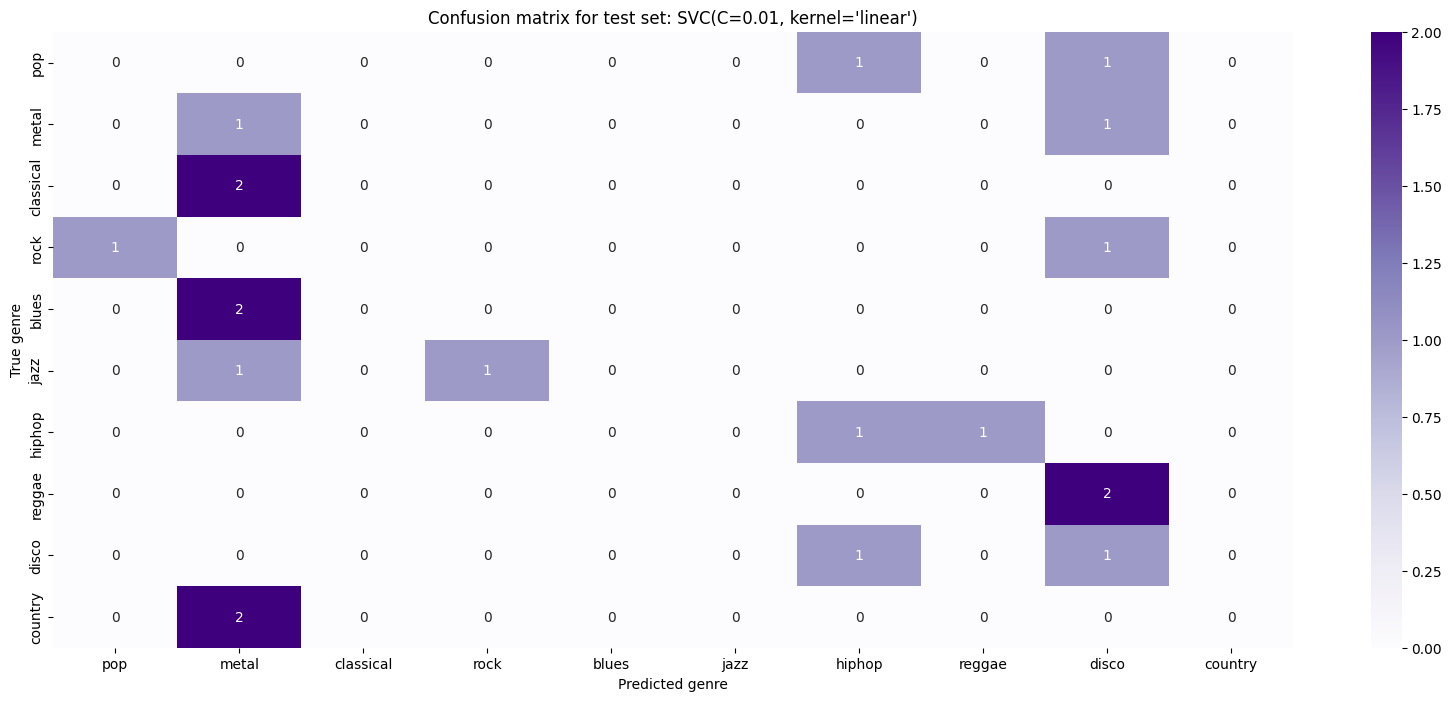

Accuracy on the test set: 15.00%


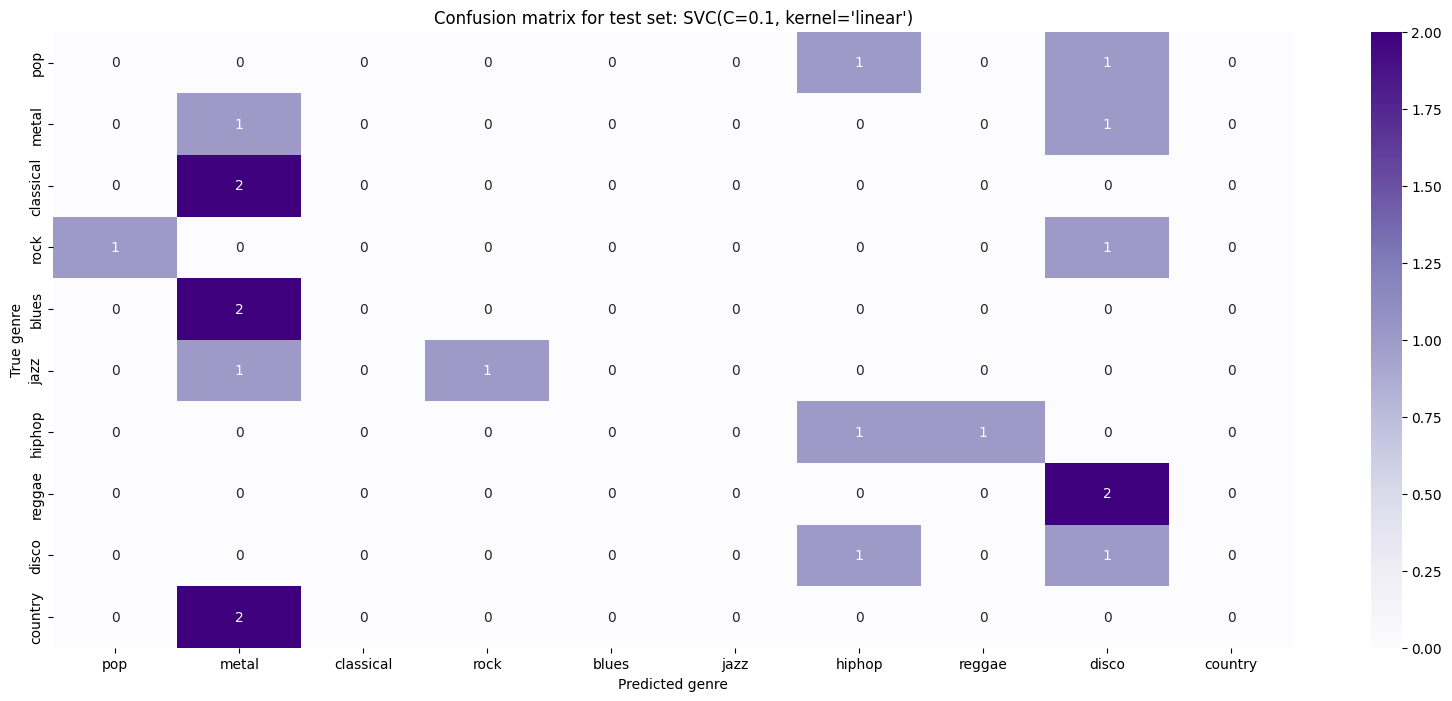

Accuracy on the test set: 15.00%


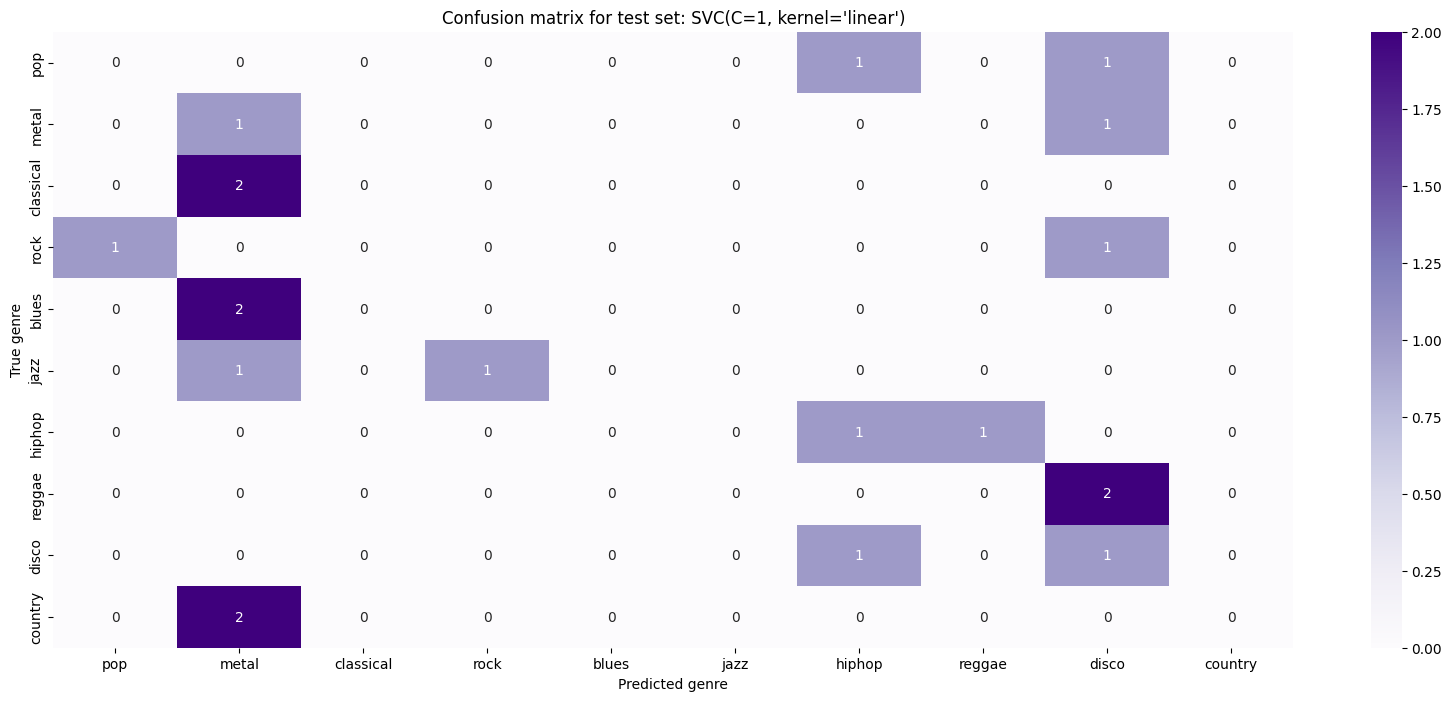

Accuracy on the test set: 15.00%


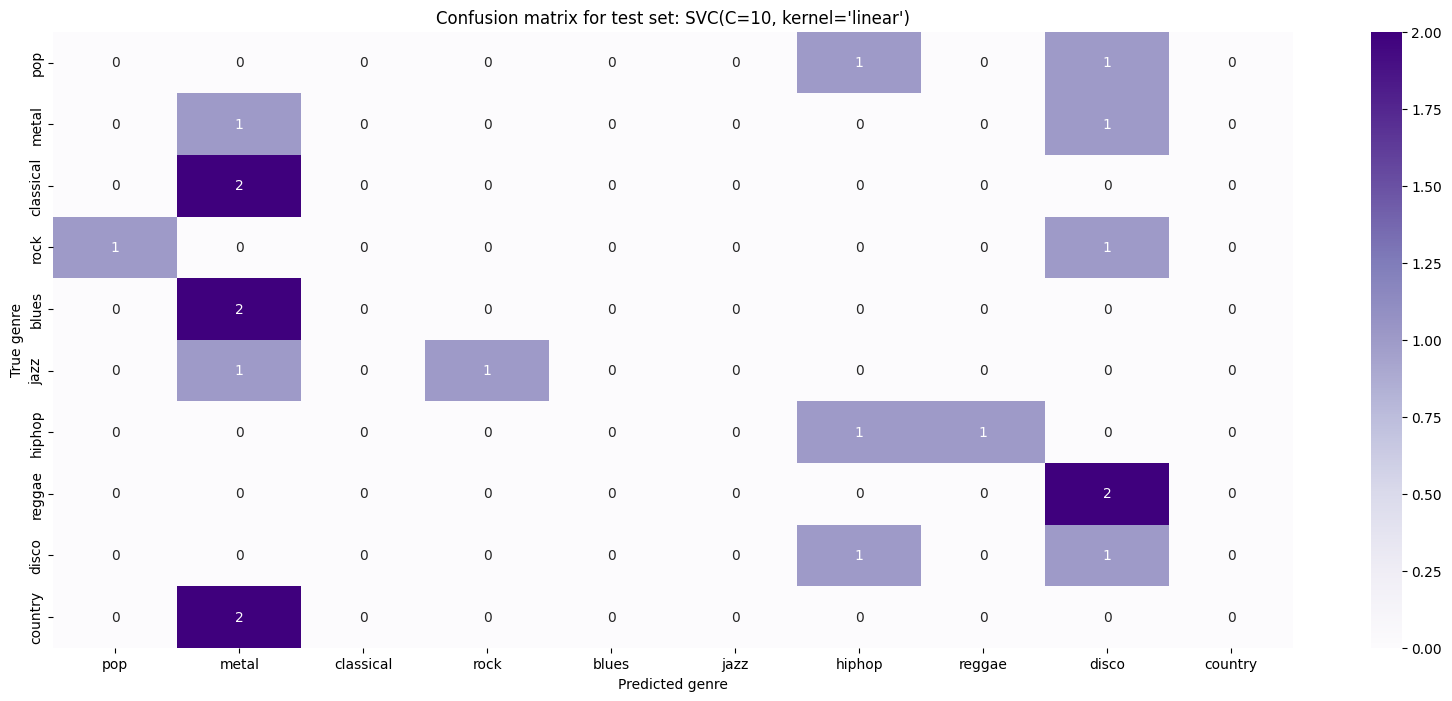

Accuracy on the test set: 15.00%


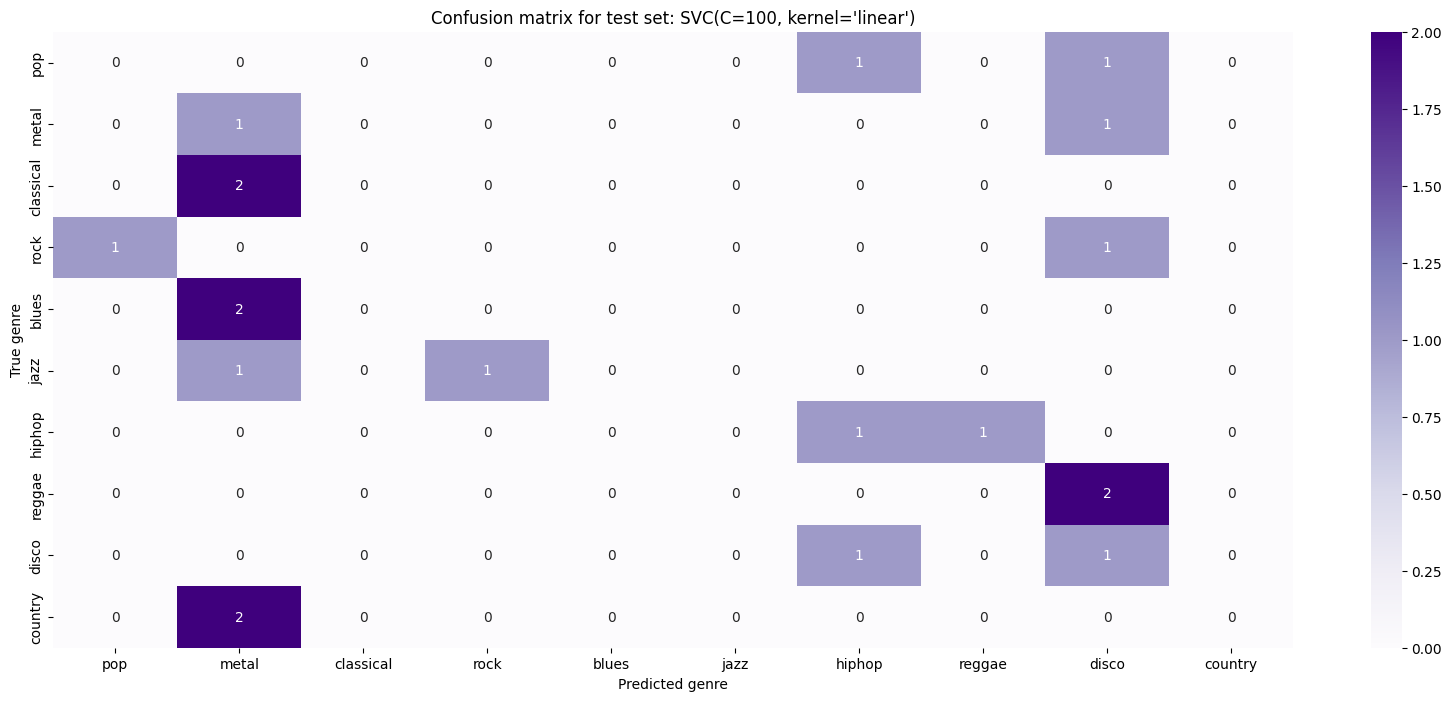

In [38]:
for model in best_models:
    y_test_pred = model.predict(test_fvector)   # prediction for every model of the test set
                                                # using only the models with 100% on training
    # Print the accuracy
    accuracy = accuracy_score(np.ravel(genre_test), y_test_pred)      # accuracy of the prediction
    print(f"Accuracy on the test set: {accuracy:.2%}")      # showing the model accuracy(%)

    # Plot the confusion matrix
    cm = confusion_matrix(np.ravel(genre_test), y_test_pred)      # representation of predicted genres and real ones

    plt.figure(figsize = (20, 8))
    sns.heatmap(cm, annot = True, fmt = "d", cmap = "Purples", xticklabels = genre_names, yticklabels = genre_names)
    plt.title("Confusion matrix for test set: " + str(model))
    plt.xlabel("Predicted genre")
    plt.ylabel("True genre")
    plt.show()
